### Import libraries

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from tsl.data import SpatioTemporalDataset
from sklearn.model_selection import train_test_split

DATA_FOLDER = '../data/'

### Load data

In [ ]:

df = pd.read_csv(os.path.join(DATA_FOLDER, 'EWZ.csv'), sep=";")


# First row: AKS, I don't know what it is
AKS = df.iloc[0]
# Second row: Unit: MWh, constant value
df.drop(index=[0, 1], inplace=True)

# delta time: 15 minutes:
# 1 hour: 4 steps
# 1 day: 96 steps
# 1 week: 672 steps

print(df.shape)
df.head()

### Convert all values to float and clear zero-sensor

In [ ]:
EPS = 1e-12

# rename and cast to datetime
df.rename(columns={"Name":"Time"}, inplace=True)
df['Time'] = pd.to_datetime(df['Time'], dayfirst=True, errors='coerce')
time = df['Time'].values

# Exclude name column
sensor_columns = df.columns[1:]
valid_column = []

print(f"before: {len(sensor_columns)} sensors")
for c in sensor_columns:
    df[c] = df[c].astype(np.float64)
    max_val = df[c].max()
    if max_val > EPS:
        valid_column.append(c)

sensor_columns = valid_column
df = df[['Time'] + valid_column]


print(f"after: {len(sensor_columns) } sensors")


### Glossary:

Wärmezähler: Heat meter

Schwimmbad: Pool

### Manual check of time series

In [8]:
def plot_daily_mean(time, values, step, title):
    time_tmp = []
    values_tmp = []
    
    for day_start in range(0, len(values), step):
        day_end = min(day_start + step, len(values))
        
        day_time = time[day_start]
        
        day_values = values[day_start:day_end]
        daily_mean = np.mean(day_values)
        
        time_tmp.append(day_time)
        values_tmp.append(daily_mean)

    plt.plot(time_tmp, values_tmp)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("MWh (Daily Mean)")
    plt.ylim(0, 1.1 * max(values_tmp))
    plt.show()

In [ ]:
# result from visual inspection
sure = set([0, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52,
53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65,
66, 67, 68, 69, 70, 71, 78, 80, 81, 82, 83, 84, 85, 86,
87, 88, 89, 90, 91, 92, 93, 94, 95,
96])

keep = []
plot = False

for idx, c in enumerate(sensor_columns):

    if idx in sure:
        keep.append(c)

    if plot:
        plot_daily_mean(df['Time'].values, df[c].values, 96, f"Sensor {idx}: {c}")


# Filter 
df = df[['Time'] + keep]
sensor_columns = keep

print(f"final: {len(sensor_columns) } sensors")
    

### Get intersection

In [ ]:
max_nz = datetime(2003, 1, 1) # random date in the past
idx_intersection = -1

for col in sensor_columns:

    values = df[col].values
    nonzero = df[col] > EPS
    nz_idx = np.argmax(nonzero) # argmax takes first occurence of max
    first_nz = df.iloc[nz_idx]['Time']
    if first_nz > max_nz:
        max_nz = first_nz
        idx_intersection = nz_idx


print(max_nz)
    
df_intersection = df.iloc[idx_intersection:]
df_intersection.set_index('Time', inplace=True)
df_intersection.head()

### Train test split

In [ ]:


# shuffle = False for causality
df_train, df_test = train_test_split(df_intersection, test_size=0.25, shuffle=False)

### Median filter on outliers

Only applied to training set to be able to do outlier detection on test set

In [ ]:

plot = True

kernel_size = 4 * 6 # 6 hours

for col in sensor_columns:
    values = df_train[col].values

    # outlier mask: within 3 std, non-negative
    mean = np.mean(values[values > EPS])
    std = np.std(values[values > EPS])
    mask = (values >= mean - 3 * std) & (values <= mean + 3 * std) & (values >= 0)

    outlier_indices = np.where(~mask)[0]

    for idx in outlier_indices:
        start = max(0, idx - kernel_size // 2)
        end = min(len(df_train[col]), idx + kernel_size // 2 + 1)

        # exclude the outlier itself from the window
        window_values = df_train[col].iloc[start:end].drop(df_train.index[idx])
        df_train.loc[df_train.index[idx], col] = np.median(window_values)


    if plot:
        plot_daily_mean(df_train.index, df_train[col].values, 96, f"Sensor {col}")


In [ ]:
# sanity check
torch_dataset_train = SpatioTemporalDataset(target=df_train,
                                      horizon=12,
                                      window=12,
                                      stride=1)


torch_dataset_test = SpatioTemporalDataset(target=df_test,
                                      horizon=12,
                                      window=12,
                                      stride=1)


torch_dataset_train.shape, torch_dataset_test.shape


In [ ]:
# save
df_train.to_csv(os.path.join(DATA_FOLDER, 'EWZ_train.csv'))
df_test.to_csv(os.path.join(DATA_FOLDER, 'EWZ_test.csv'))

df_cleaned = pd.concat([df_train, df_test])
df_cleaned.to_csv(os.path.join(DATA_FOLDER, 'EWZ_cleaned.csv'))

In [2]:
df = pd.read_csv(os.path.join(DATA_FOLDER, 'EWZ_cleaned.csv'), index_col=0)
df.index = pd.to_datetime(df.index)
dates = df.index

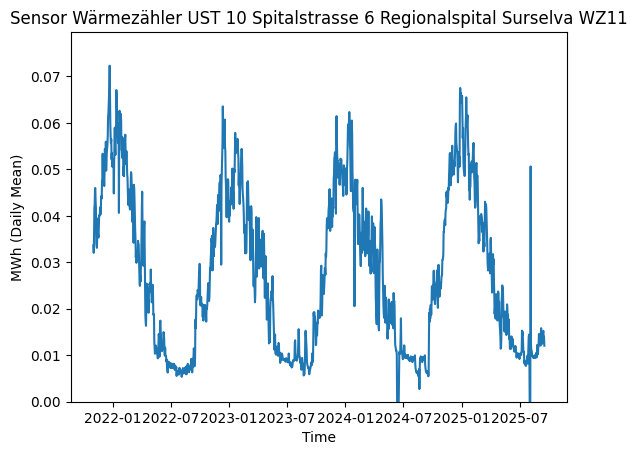

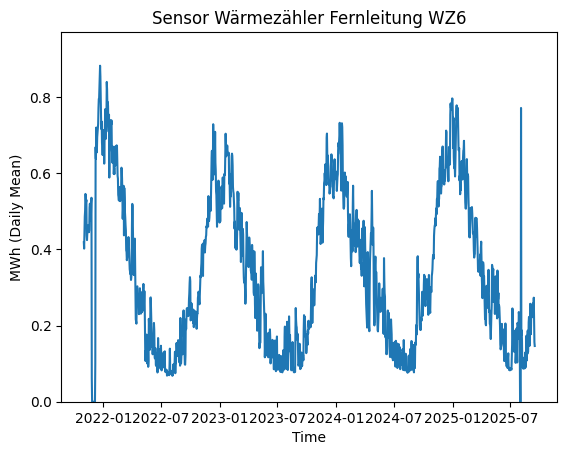

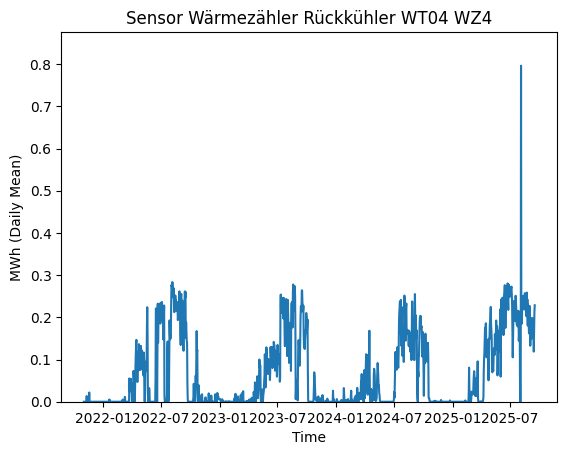

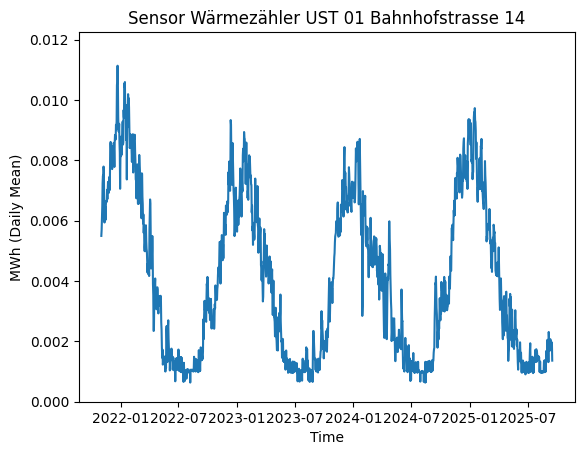

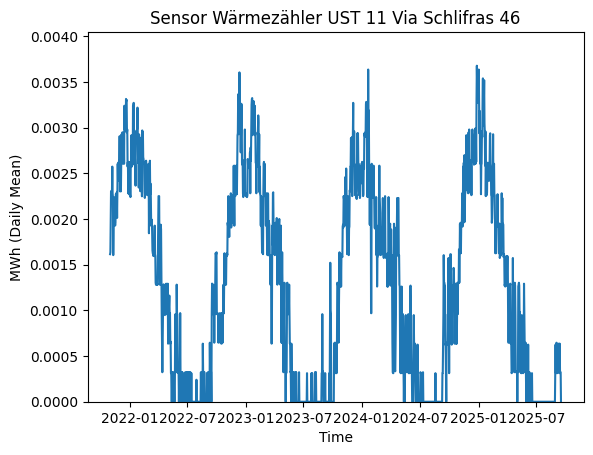

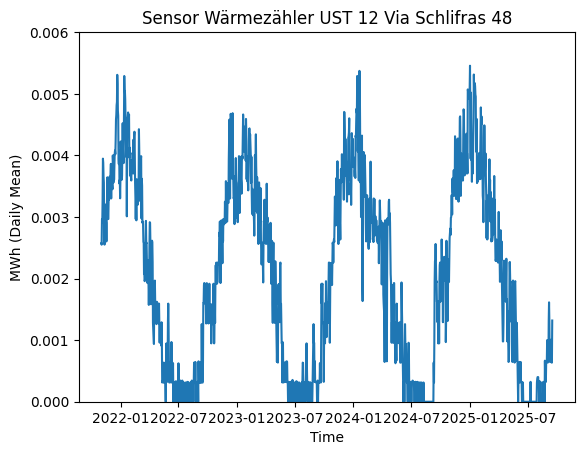

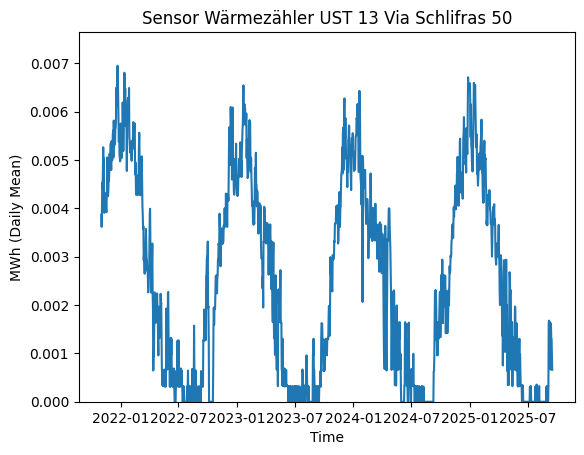

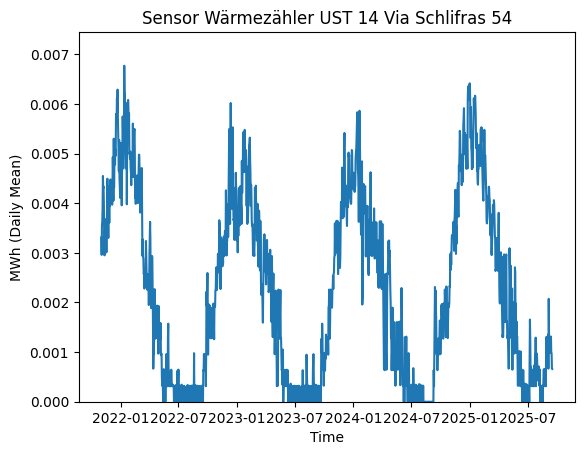

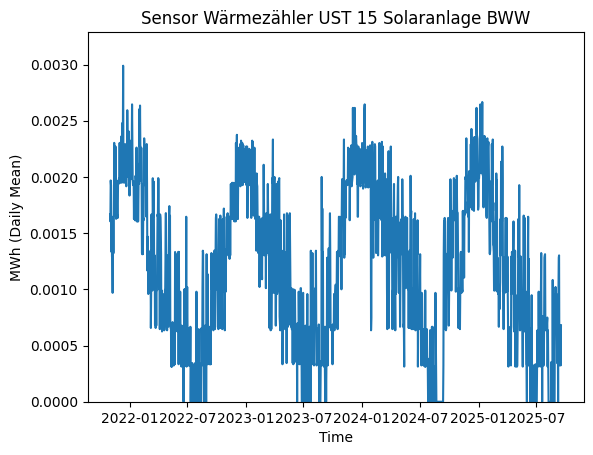

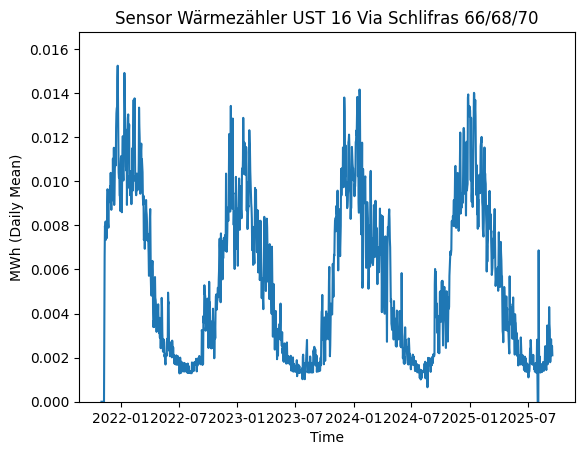

In [14]:


for i,c in enumerate(df.columns):
    # plt.figure(figsize=(10, 4))
    # plt.plot(dates, df[c])
    # plt.title(f'Sensor: {c}')
    
    # plt.xticks([])
    # plt.ylim(0, df[c][:10000].max() * 1.1)
    # plt.show()

    plot_daily_mean(dates, df[c].values, 96, f"Sensor {c}")

    if i == 9:
        break

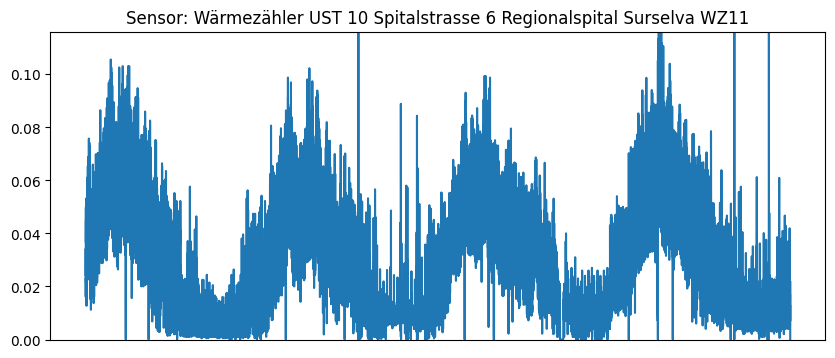

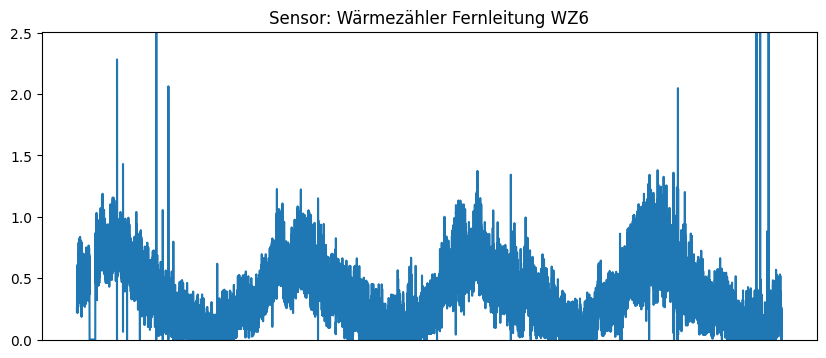

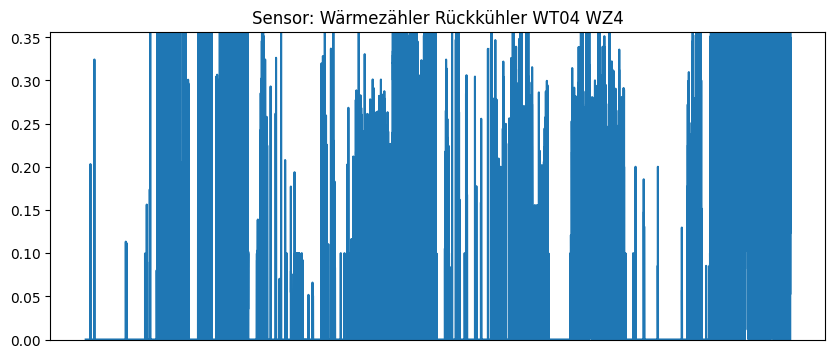

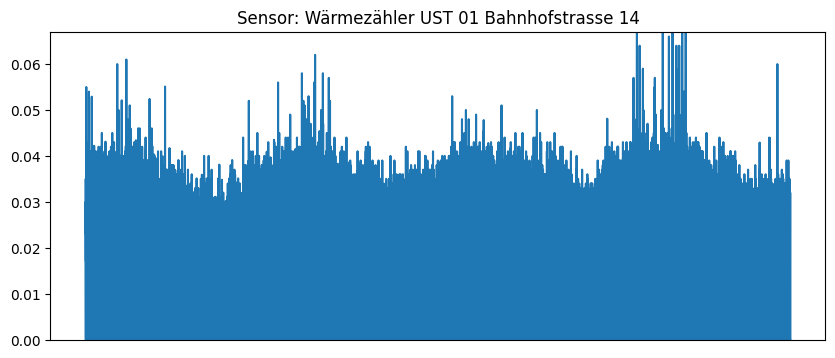

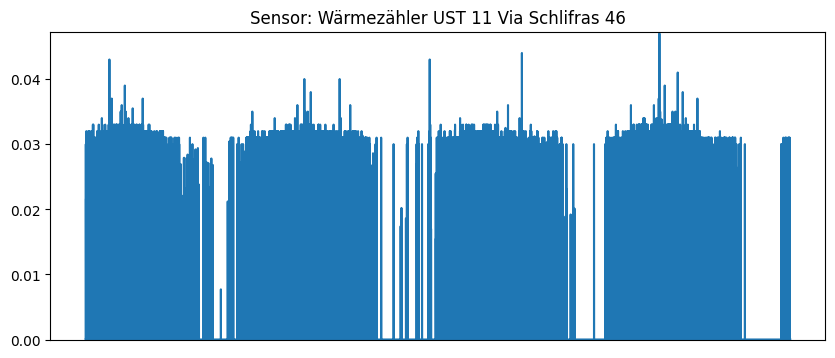

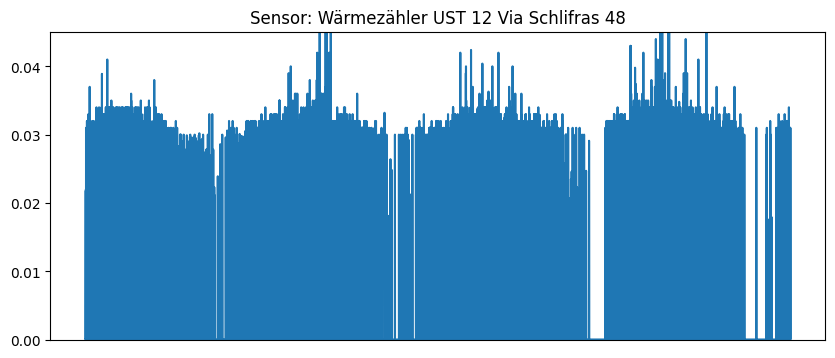

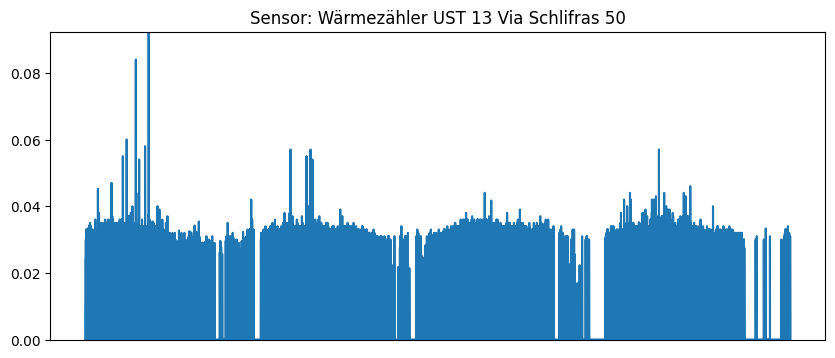

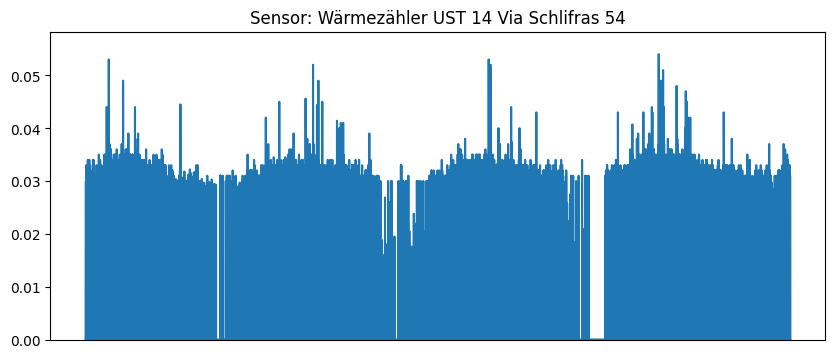

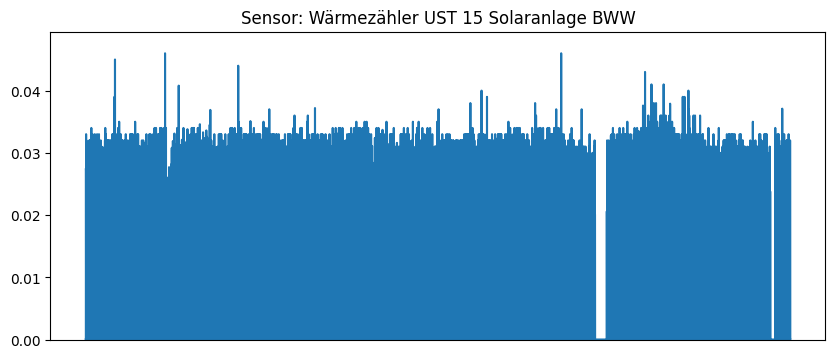

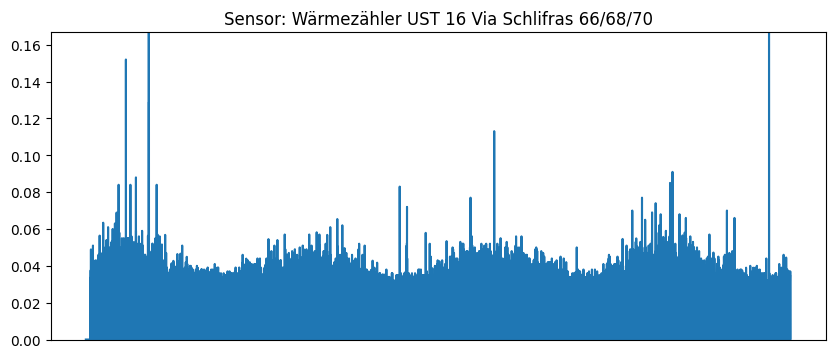

In [12]:

for i,c in enumerate(df.columns):
    plt.figure(figsize=(10, 4))
    plt.plot(dates, df[c])
    plt.title(f'Sensor: {c}')
    
    plt.xticks([])
    plt.ylim(0, df[c][:10000].max() * 1.1)
    plt.show()

    if i == 9:
        break